GRSW1 - observations - single analysis

This notebook enable to reproduce some of the figures of the first grsw paper, focusing on individual pairs


First we load an analysis of a system. If you want to use your own data, replace this step but make sure your data has the correct structure

In [1]:
from resonantstate.data_download  import get_metadata_observations, download_observations_samples
from resonantstate.constants import *
dataframe_observations = get_metadata_observations()

star='Kepler-1705'
pair=(0,1) #We want to analyse the resonant state of the first pair of planets

dataframe_system = dataframe_observations[(dataframe_observations["star_name"]==star)]
dataframe_system_dl = dataframe_system[(dataframe_system['author_name']=='Leleu')&(dataframe_system['default']==True)]


list_analysis = download_observations_samples(dataframe_system_dl, download_destination=None)

df_samples=list_analysis[0]['samples']
nb_planets=list_analysis[0]['nb_planets']

print('the structure of the data is a pandaframe with the columns : ',df_samples.keys())

the structure of the data is a pandaframe with the columns :  Index(['sample_index', 'mean_longitude_deg_0', 'period_days_0', 'k_0', 'h_0',
       'inclination_deg_0', 'longitude_of_ascending_node_deg_0',
       'mass_planet_star_ratio_0', 'radius_planet_star_ratio_0',
       'mean_longitude_deg_1', 'period_days_1', 'k_1', 'h_1',
       'inclination_deg_1', 'longitude_of_ascending_node_deg_1',
       'mass_planet_star_ratio_1', 'radius_planet_star_ratio_1',
       'mass_star_m_sun', 'radius_star_r_sun'],
      dtype='object')


We then integrate the first sample using rebound and plot the evolution of the orbital elements of planet 1

Text(0, 0.5, '$P_1$ [day]')

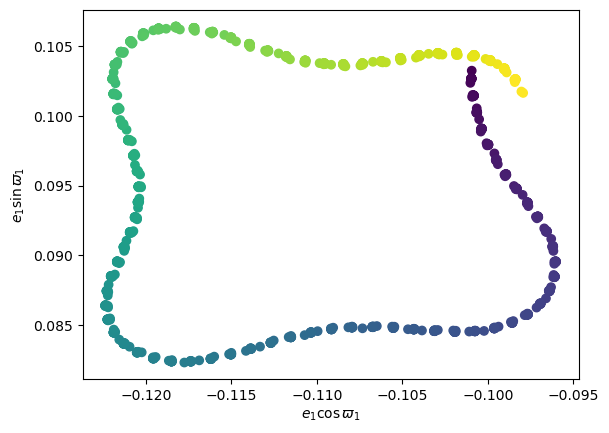

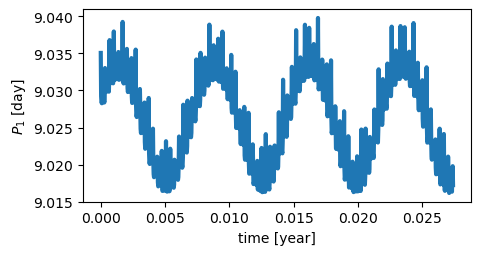

In [2]:
from rebound_db import * 
import matplotlib.pyplot as plt

duration=10 # in years


times,la,a,P,e,pomega=rebound_sim_coplanar(df_samples,pair,0,duration)



plt.figure(1)
plt.scatter(e[0]*np.cos(pomega[0]),e[0]*np.sin(pomega[0]),c=times)
plt.xlabel('$e_1 \cos \\varpi_1$')
plt.ylabel('$e_1 \sin \\varpi_1$')


plt.figure(2,figsize=(5,2.5))
plt.plot(times/365.25,P[0],alpha=1,zorder=2,lw=3) 
plt.xlabel('time [year]')
plt.ylabel('$P_1$ [day]')

We then check the evolution for 20 other samples

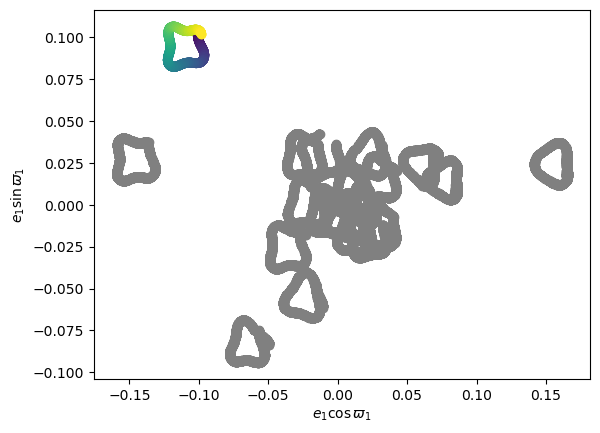

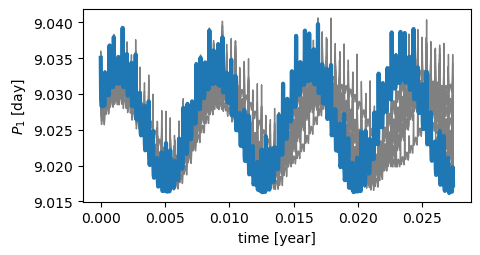

In [3]:

times,la,a,P,e,pomega=rebound_sim_coplanar(df_samples,pair,0,duration)

plt.figure(1)
plt.scatter(e[0]*np.cos(pomega[0]),e[0]*np.sin(pomega[0]),c=times)
plt.xlabel('$e_1 \cos \\varpi_1$')
plt.ylabel('$e_1 \sin \\varpi_1$')


plt.figure(2,figsize=(5,2.5))
plt.plot(times/365.25,P[0],alpha=1,zorder=2,lw=3) 
plt.xlabel('time [year]')
plt.ylabel('$P_1$ [day]')

TId=np.arange(0,1000,50)

for Id in TId[1:]:
    times,la,a,P,e,pomega=rebound_sim_coplanar(df_samples,pair,Id,duration)
    plt.figure(1)
    plt.scatter(e[0]*np.cos(pomega[0]),e[0]*np.sin(pomega[0]),c='grey')
    plt.figure(2)
    plt.plot(times/365.25,P[0],alpha=1,zorder=1,lw=1,c='grey') 


The evolution of $e_1$,$\varpi_1$ can take very different values, but their evolution is similar over the first three years of data. The evolution of the period is more consistant across the posterior. We then check the TTV signal along the same samples.  

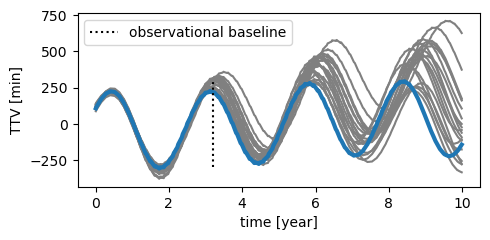

In [4]:
from resonantstate import ttv

plt.figure(figsize=(5,2.5))


transits=ttv.forward_modeling(df_samples.iloc[0,:].values,2,0, 2/21, duration*365.25,input_flag=1)
Vt0_1=transits[0]
P1mean=(Vt0_1[1:]-Vt0_1[:-1]).mean()
TTV1=ttv.get_TTV_detrend(Vt0_1,P1mean)
plt.plot(Vt0_1/365.25,TTV1*24*60,alpha=1,zorder=2,lw=3) 

for Id in TId[1:]:
    transits=ttv.forward_modeling(df_samples.iloc[Id,:].values,2,0, 2/21, duration*365.25,input_flag=1)
    t0=transits[0]
    residuals=t0-Vt0_1
    plt.plot(Vt0_1/365.25,(TTV1+residuals)*24*60,alpha=1,c='grey',zorder=1) 
 

plt.vlines(x=3.2,ymin=-300,ymax=+300,linestyles=':',colors='black',label='observational baseline')
plt.xlabel('time [year]')
plt.ylabel('TTV [min]')
plt.legend()
plt.tight_layout()

The transit timings, whose TTVs are induced by the resonant motion, are similar for the duration of the observational baseline. Indeed, we verify that the position in the second fundamental model ($\Delta_{MMR},e_r$ plane) is similar for the whole posterior, depsite the value of $e_1$, $\varpi_1$ being very different:

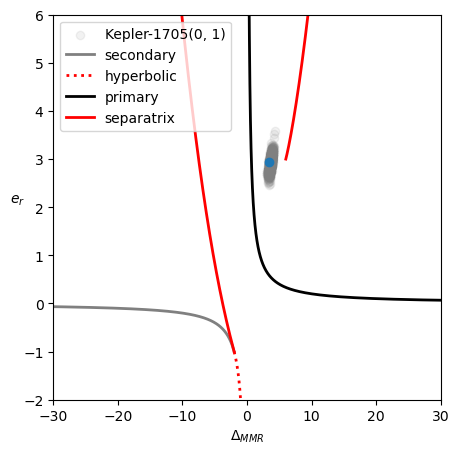

In [5]:
from resonantstate import utils
from resonantstate.ell2SFM import *


delta, DMMR, er, Der, es, IR, p=utils.get_SFM_quantities(df_samples,(0,1))

fig, ax1 = plt.subplots(1, 1, figsize=(5,5))

ax1.scatter(DMMR,er,label=star+str(pair),alpha=.1,color='gray')
ax1.scatter(DMMR[0],er[0],alpha=1,color='C0')
er_lim=(-2,6)
DMMR_lim=(-30,30)


plot_topology_DMMR(ax1, DMMR_lim, er_lim,dark=False,linewidth=2,legend=True)
plt.legend(loc='upper left')


It is because $e_r$ is the relevant quantity to describe the resonant state of the pair, and is constrained by the TTVs, while $e_s$ is broadly unconstrained by this analysis. 

In [6]:
print('$e_r$ has a precision of : ',er.std()/er.mean())
print('while $e_s$ has a precision of : ',es.std()/es.mean())

$e_r$ has a precision of :  0.04971868170324573
while $e_s$ has a precision of :  1.278370038135279
